In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

# Regressão Linear por Pseudo-inversa Generalizada

Neste notebook, será implementada a solução da **regressão linear** por **mínimos quadrados**, utilizando a **pseudo-inversa generalizada**. A ideia central é representar a variável resposta como uma combinação linear das variáveis do problema,

$$
\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}
$$

em que $\mathbf{X}$ é a matriz de dados e $\mathbf{w}$ é o vetor de parâmetros do modelo.

O objetivo é encontrar o vetor $\mathbf{w}$ que minimiza o erro quadrático entre os valores observados $\mathbf{y}$ e os valores preditos $\hat{\mathbf{y}}$. Isso leva ao problema:

$$
\min_{\mathbf{w}} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2
$$

Derivando a função custo e igualando o gradiente a zero, obtemos as **equações normais**:

$$
\mathbf{X}^T \mathbf{X}\mathbf{w} = \mathbf{X}^T \mathbf{y}
$$

Se $\mathbf{X}^T\mathbf{X}$ for invertível, a solução pode ser escrita como:

$$
\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

que corresponde à solução por pseudo-inversa utilizada neste notebook.

In [21]:
def solucao_pseudo_inversa(X,y,intercept=True):
    """
    Inputs: X: matriz de dados (n_amostras, n_atributos)
            y: vetor de respostas (n_amostras,)
    Output: vetor de coeficientes (n_atributos,)
    """
    if intercept==True:
        X = np.column_stack((X, np.ones(X.shape[0])))
    
    return inv(X.T @ X) @ X.T @ y

def predict(X,w,intercept=True):
    """
    Inputs: X: matriz de dados (n_amostras, n_atributos)
            w: vetor de coeficientes (n_atributos,)
    Output: vetor de respostas preditas (n_amostras,)
    """
    if intercept==True:
        X = np.column_stack((X, np.ones(X.shape[0])))
    
    return X @ w

def erro_quadratico_medio(y_true, y_pred):
    """
    Inputs: y_true: vetor de respostas verdadeiras (n_amostras,)
            y_pred: vetor de respostas preditas (n_amostras,)
    Output: valor do erro quadrático médio
    """
    return np.mean((y_true - y_pred)**2)

def erro_absoluto_medio(y_true, y_pred):
    """
    Inputs: y_true: vetor de respostas verdadeiras (n_amostras,)
            y_pred: vetor de respostas preditas (n_amostras,)
    Output: valor do erro absoluto médio
    """
    return np.mean(np.abs(y_true - y_pred))

In [4]:
# Criando uma função do tipo: y = 3x + 2

x1 = np.random.rand(100) * 10
y = 3 * x1 + 2 + np.random.normal(0, scale=2, size=x1.shape)

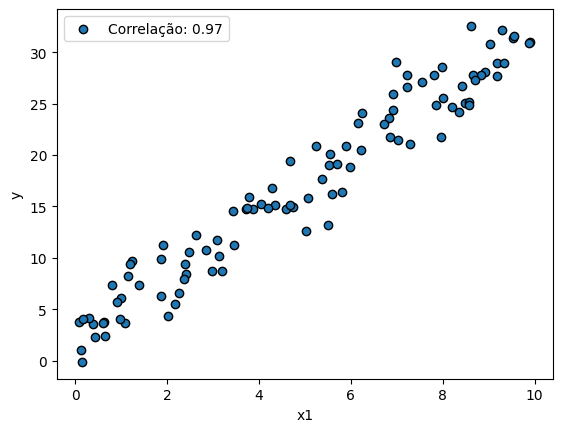

In [6]:
fig,ax = plt.subplots()
ax.scatter(x1, y, edgecolor='black',label=f'Correlação: {np.corrcoef(x1,y)[0,1]:.2f}')
ax.set_xlabel('x1')
ax.set_ylabel('y')
ax.legend()

In [13]:
w = solucao_pseudo_inversa(x1.reshape(-1,1), y)
print(f'Coeficientes encontrados: {w}')

Coeficientes encontrados: [2.95912529 2.36426825]


In [24]:
y_pred = predict(x1.reshape(-1,1), w)
y_pred_sorted = predict(np.sort(x1).reshape(-1,1), w)

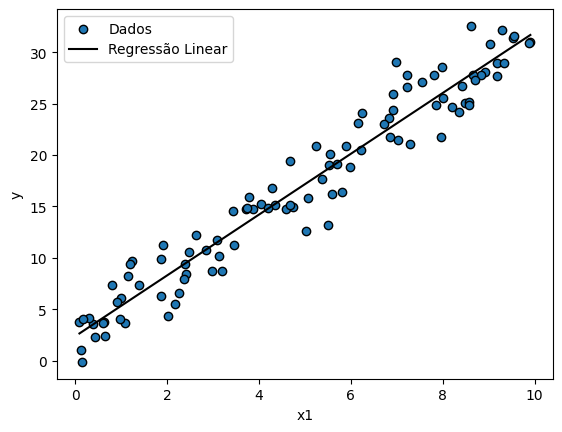

In [29]:
fig, ax = plt.subplots()
ax.scatter(x1, y, edgecolor='black', label='Dados')
ax.plot(np.sort(x1), y_pred_sorted, color='black', label='Regressão Linear')
ax.set_xlabel('x1')
ax.set_ylabel('y')
ax.legend()

In [30]:
# Estimando o erro do modelo
print(f'Erro Quadrático Médio: {erro_quadratico_medio(y, y_pred):.3f}')
print(f'Erro Absoluto Médio: {erro_absoluto_medio(y, y_pred):.3f}')

Erro Quadrático Médio: 4.743
Erro Absoluto Médio: 1.784
